In [ ]:
import pandas as pd
import numpy as np
import heapq
from scipy.special import gammaln, pdtr

MU    = 2.55          # service rate per physician (patients/hr), EDBA benchmark
C_W   = 120.0         # $ penalty per patient-hour of waiting
ALPHA = 2.0           # equity weighting dial
BUDGET = 8            # additional physicians; ~15% of baseline capacity.
                      # See budget sweep — B=40 implies 74% capacity growth,
                      # far outside any realistic staffing scenario.

In [ ]:
# Load your implied-capacity results (output of the brentq inversion step)
hospitals = pd.read_csv("../data/processed/nj_hospital_implied_capacity_results.csv")  # <-- swap in your actual filename

# Load the NJ county-level SVI data
svi = pd.read_csv("../data/raw/NEWJERSEY_COUNTY.csv")

print(hospitals.columns.tolist())
print(svi.columns.tolist())

['name_match', 'Facility Name', 'Wq_hours', 'lambda_per_hour', 'County_clean', 'implied_c', 'implied_c_rounded']
['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'M_HU', 'E_HH', 'M_HH', 'E_POV150', 'M_POV150', 'E_UNEMP', 'M_UNEMP', 'E_HBURD', 'M_HBURD', 'E_NOHSDP', 'M_NOHSDP', 'E_UNINSUR', 'M_UNINSUR', 'E_AGE65', 'M_AGE65', 'E_AGE17', 'M_AGE17', 'E_DISABL', 'M_DISABL', 'E_SNGPNT', 'M_SNGPNT', 'E_LIMENG', 'M_LIMENG', 'E_MINRTY', 'M_MINRTY', 'E_MUNIT', 'M_MUNIT', 'E_MOBILE', 'M_MOBILE', 'E_CROWD', 'M_CROWD', 'E_NOVEH', 'M_NOVEH', 'E_GROUPQ', 'M_GROUPQ', 'EP_POV150', 'MP_POV150', 'EP_UNEMP', 'MP_UNEMP', 'EP_HBURD', 'MP_HBURD', 'EP_NOHSDP', 'MP_NOHSDP', 'EP_UNINSUR', 'MP_UNINSUR', 'EP_AGE65', 'MP_AGE65', 'EP_AGE17', 'MP_AGE17', 'EP_DISABL', 'MP_DISABL', 'EP_SNGPNT', 'MP_SNGPNT', 'EP_LIMENG', 'MP_LIMENG', 'EP_MINRTY', 'MP_MINRTY', 'EP_MUNIT', 'MP_MUNIT', 'EP_MOBILE', 'MP_MOBILE', 'EP_CROWD', 'MP_CROWD', 'EP_NOVEH', 'MP_NOVEH', '

In [ ]:
# Rename to consistent working names
df = hospitals.rename(columns={
    'Facility Name': 'hospital',
    'County_clean': 'county',
    'lambda_per_hour': 'lambda',
})

# Normalize county name casing/whitespace so the join doesn't drop rows
svi_clean = svi[['COUNTY', 'RPL_THEMES']].rename(
    columns={'COUNTY': 'county', 'RPL_THEMES': 'SVI'}
)
svi_clean['county'] = (
    svi_clean['county']
    .str.replace(' County', '', regex=False)
    .str.strip()
    .str.upper()
)
df['county'] = df['county'].str.strip().str.upper()

df = df.merge(svi_clean, on='county', how='left')

missing = df[df['SVI'].isna()]
if len(missing) > 0:
    print("WARNING — unmatched counties:")
    print(missing[['hospital', 'county']])
assert df['SVI'].notna().all(), "SVI merge failed — check county name formatting above."

# SVI sanity check: RPL_THEMES is a percentile in [0,1]; CDC codes missing as -999
assert df['SVI'].between(0, 1).all(), f"SVI out of range:\n{df.loc[~df['SVI'].between(0,1), ['hospital','county','SVI']]}"

# Equity weight
df['w'] = 1 + ALPHA * df['SVI']

# CONTINUOUS baseline. implied_c came from inverting the observed Wq, so this is
# the only value that reproduces the observed wait. Rounding it moves the system
# off the fitted point — badly, since implied_c sits near the steep part of Erlang C.
df['c'] = df['implied_c'].astype(float)
df['c_start'] = df['c'].copy()

# Stability holds by construction (brentq searched only c > lambda/mu).
# Assert instead of bumping: a failure here is an upstream inversion bug.
assert (df['c'] * MU > df['lambda']).all(), "unstable baseline — check inversion"

print(f"{len(df)} hospitals | c_start range {df['c'].min():.2f} – {df['c'].max():.2f}")

22 hospitals | c_start range 1.21 – 4.89


In [ ]:
import math
from scipy.special import gammaln, pdtr

def log_erlang_c(c, R):
    """
    Continuous-c Erlang C, P(wait). Uses the Poisson-CDF identity for the
    partial sum so c need not be an integer. Same math as the inversion step,
    which is what makes the round trip exact.
    """
    rho = R / c
    if rho >= 1.0:
        return 1.0
    log_t2 = c * np.log(R) - gammaln(c + 1) - np.log(1 - rho)
    t2 = np.exp(log_t2)
    t1 = np.exp(R) * pdtr(int(math.floor(c)) - 1, R)
    return t2 / (t1 + t2)


def expected_wait(c, lam, mu=MU):
    """E[W]: expected wait in queue (hours) with c servers."""
    R = lam / mu
    p_wait = log_erlang_c(c, R)
    if p_wait >= 1.0:
        return float('inf')
    return p_wait / (c * mu - lam)

In [ ]:
chk = df.copy()
chk['E_W_at_cstart_min'] = chk.apply(lambda r: expected_wait(r['c_start'], r['lambda']) * 60, axis=1)
chk['observed_min']      = chk['Wq_hours'] * 60
chk['ratio']             = chk['E_W_at_cstart_min'] / chk['observed_min']
display(chk[['hospital','lambda','implied_c','observed_min','E_W_at_cstart_min','ratio']]
        .sort_values('ratio'))
print(f"mean ratio {chk['ratio'].mean():.6f} | min {chk['ratio'].min():.6f} | max {chk['ratio'].max():.6f}")
assert np.allclose(chk['ratio'], 1.0, atol=1e-3), "round trip still broken"

,hospital,lambda,implied_c,observed_min,E_W_at_cstart_min,ratio
0,HACKENSACK UNIVERSITY MEDICAL CENTER,9.678187,3.910194,197.0,197.0,1.0
5,NEWTON MEDICAL CENTER,4.488813,1.893696,169.0,169.0,1.0
18,JFK UNIVERSITY MEDICAL CENTER,4.684900,1.953238,196.0,196.0,1.0
1,NEWARK BETH ISRAEL MEDICAL CENTER,5.704789,2.366595,169.0,169.0,1.0
11,OVERLOOK MEDICAL CENTER,8.843379,3.584517,192.0,192.0,1.0
13,VIRTUA WILLINGBORO HOSPITAL,2.845186,1.234544,181.0,181.0,1.0
21,HUDSON REGIONAL HOSPITAL,3.933546,1.670614,174.0,174.0,1.0
15,JERSEY CITY MEDICAL CENTER,11.684947,4.700741,190.0,190.0,1.0
16,MONMOUTH MEDICAL CENTER,3.585842,1.573954,129.0,129.0,1.0
12,VIRTUA MOUNT HOLLY HOSPITAL,5.957705,2.443828,207.0,207.0,1.0


mean ratio 1.000000 | min 1.000000 | max 1.000000


In [ ]:
def marginal_savings(c, lam, mu=MU, c_w=C_W):
    """
    Dollar value of adding one more doctor, going from c to c+1.
    MS = C_w * lambda * (E[W](c) - E[W](c+1))
    """
    ew_now  = expected_wait(c, lam, mu)
    ew_next = expected_wait(c + 1, lam, mu)
    if ew_now == float('inf') or ew_next == float('inf'):
        return float('inf')  # unstable — always prioritize
    return c_w * lam * (ew_now - ew_next)


def greedy_equity_allocation(df, budget, verbose=True):
    """
    Distributes `budget` additional doctors across hospitals using a
    weighted-greedy priority queue. Score = w_i * MarginalSavings_i(c_i).

    c is continuous (the inverted implied capacity); doctors are added as
    integer increments on top of that fractional baseline.

    Returns (updated dataframe, allocation log dataframe).
    """
    df = df.copy()
    heap = []

    for idx, row in df.iterrows():
        ms = marginal_savings(row['c'], row['lambda'])
        score = row['w'] * ms
        heapq.heappush(heap, (-score, idx))

    log = []
    remaining = budget

    while remaining > 0 and heap:
        neg_score, idx = heapq.heappop(heap)
        score = -neg_score

        df.at[idx, 'c'] += 1
        remaining -= 1

        log.append({
            'hospital': df.at[idx, 'hospital'],
            'new_c': float(df.at[idx, 'c']),
            'score': score,
            'doctors_remaining': remaining
        })

        next_ms = marginal_savings(df.at[idx, 'c'], df.at[idx, 'lambda'])
        next_score = df.at[idx, 'w'] * next_ms
        heapq.heappush(heap, (-next_score, idx))

        if verbose:
            print(f"Doctor -> {df.at[idx,'hospital']:32s} | new c = {df.at[idx,'c']:6.2f} "
                  f"| score = ${score:,.2f} | {remaining} remaining")

    return df, pd.DataFrame(log)

In [ ]:
final_df, allocation_log = greedy_equity_allocation(df, BUDGET)

final_df['gained'] = final_df['c'] - final_df['c_start']

print("\n====== FINAL ALLOCATION ======")
cols = ['hospital', 'county', 'SVI', 'w', 'lambda', 'c_start', 'c', 'gained']
print(final_df.sort_values('gained', ascending=False)[cols]
      .to_string(index=False, float_format=lambda x: f"{x:.2f}"))

print(f"\nallocated {final_df['gained'].sum():.0f} of {BUDGET} "
      f"across {(final_df['gained'] > 0).sum()} hospitals")
print(f"largest single allocation: {final_df['gained'].max():.0f}")

final_df.to_csv("../data/processed/nj_ed_final_allocation.csv", index=False)
allocation_log.to_csv("../data/processed/nj_ed_allocation_log.csv", index=False)

Doctor -> INSPIRA MEDICAL CENTER VINELAND  | new c =   5.89 | score = $13,972.46 | 7 remaining
Doctor -> JERSEY CITY MEDICAL CENTER       | new c =   5.70 | score = $9,961.93 | 6 remaining
Doctor -> OVERLOOK MEDICAL CENTER          | new c =   4.58 | score = $7,986.40 | 5 remaining
Doctor -> HACKENSACK UNIVERSITY MEDICAL CENTER | new c =   4.91 | score = $7,147.70 | 4 remaining
Doctor -> PALISADES MEDICAL CENTER         | new c =   3.92 | score = $6,724.23 | 3 remaining
Doctor -> COOPERMAN BARNABAS MEDICAL CENTER | new c =   4.45 | score = $5,330.10 | 2 remaining
Doctor -> NEWARK BETH ISRAEL MEDICAL CENTER | new c =   3.37 | score = $5,284.09 | 1 remaining
Doctor -> COMMUNITY MEDICAL CENTER         | new c =   3.58 | score = $4,084.68 | 0 remaining

====== FINAL ALLOCATION ======
                            hospital     county  SVI    w  lambda  c_start    c  gained
HACKENSACK UNIVERSITY MEDICAL CENTER     BERGEN 0.50 2.00    9.68     3.91 4.91    1.00
   NEWARK BETH ISRAEL MEDICAL CEN

In [ ]:
final_df['E_W_before_min'] = final_df.apply(
    lambda r: expected_wait(r['c_start'], r['lambda']) * 60, axis=1
)
final_df['E_W_after_min'] = final_df.apply(
    lambda r: expected_wait(r['c'], r['lambda']) * 60, axis=1
)
final_df['minutes_saved'] = final_df['E_W_before_min'] - final_df['E_W_after_min']

final_df[['hospital', 'SVI', 'c_start', 'c', 'E_W_before_min', 'E_W_after_min', 'minutes_saved']]

,hospital,SVI,c_start,c,E_W_before_min,E_W_after_min,minutes_saved
0,HACKENSACK UNIVERSITY MEDICAL CENTER,0.50,3.910194,4.910194,197.0,12.365719,184.634281
1,NEWARK BETH ISRAEL MEDICAL CENTER,0.95,2.366595,3.366595,169.0,9.300723,159.699277
2,PALISADES MEDICAL CENTER,0.70,2.922435,3.922435,207.0,11.699035,195.300965
3,CLARA MAASS MEDICAL CENTER,0.95,1.577917,1.577917,138.0,138.000000,0.000000
4,MORRISTOWN MEDICAL CENTER,0.10,2.457243,2.457243,240.0,240.000000,0.000000
5,NEWTON MEDICAL CENTER,0.05,1.893696,1.893696,169.0,169.000000,0.000000
6,VIRTUA OUR LADY OF LOURDES HOSPITAL,0.80,1.574192,1.574192,161.0,161.000000,0.000000
7,INSPIRA MEDICAL CENTER VINELAND,1.00,4.892332,5.892332,204.0,12.996125,191.003875
8,RIVERVIEW MEDICAL CENTER,0.20,1.754333,1.754333,206.0,206.000000,0.000000
9,RARITAN BAY MEDICAL CENTER,0.55,1.531993,1.531993,174.0,174.000000,0.000000


In [ ]:
average_minutes_saved = final_df['minutes_saved'].mean()
print(f"Average minutes saved across all hospitals: {average_minutes_saved:.2f} minutes")

Average minutes saved across all hospitals: 62.31 minutes


In [ ]:
t0 = df.copy()
t0['c'] = t0['c_start'].copy()
t0['w'] = 1.0                      # alpha = 0 → w = 1 + 0*SVI
r0, _ = greedy_equity_allocation(t0, BUDGET, verbose=False)

r0['minutes_saved'] = r0.apply(
    lambda r: (expected_wait(r['c_start'], r['lambda'])
               - expected_wait(r['c'], r['lambda'])) * 60, axis=1)

print(f"alpha=0  average minutes saved: {r0['minutes_saved'].mean():.2f}")

alpha=0  average minutes saved: 69.44


In [ ]:
for a in [0, 2]:
    t = df.copy()
    t['c'] = t['c_start'].copy()
    t['w'] = 1 + a * t['SVI']
    res, _ = greedy_equity_allocation(t, BUDGET, verbose=False)
    saved = res.apply(lambda r: (expected_wait(r['c_start'], r['lambda'])
                                 - expected_wait(r['c'], r['lambda'])) * 60, axis=1)
    print(f"alpha={a}: {saved.mean():.2f} min")

alpha=0: 69.44 min
alpha=2: 62.31 min


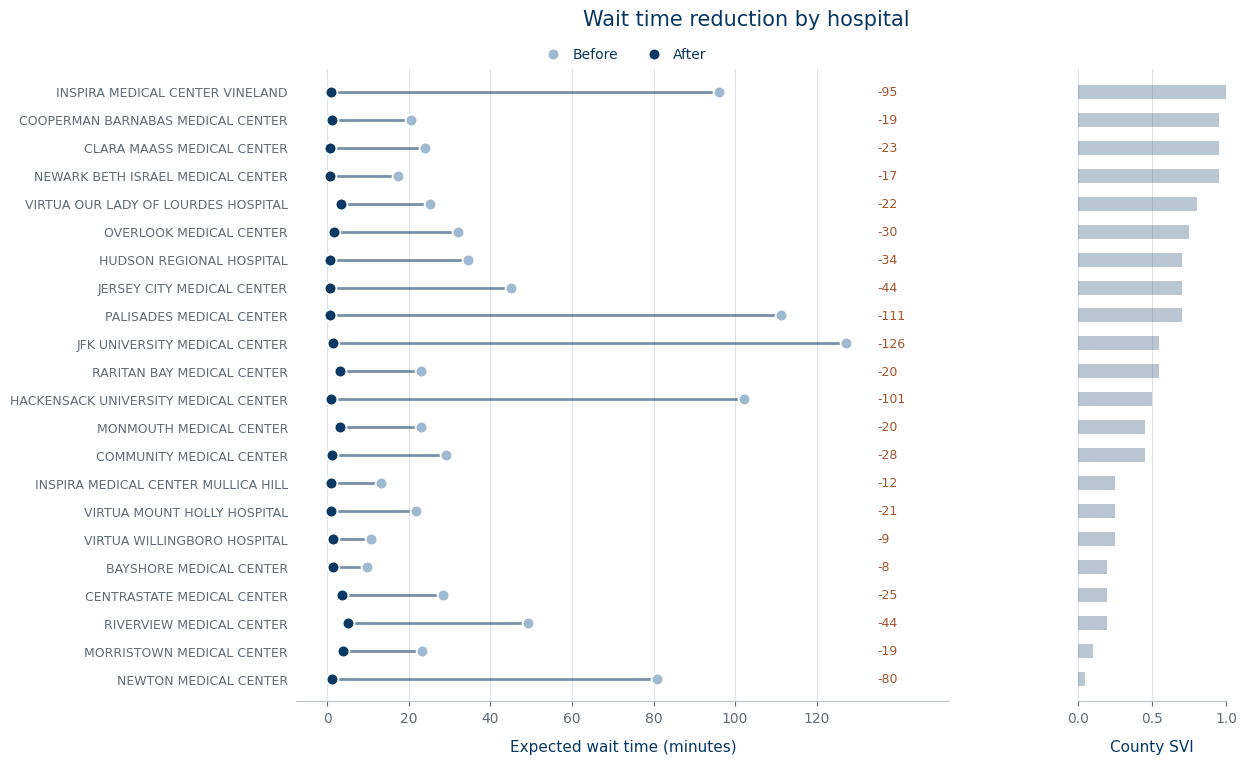

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

NAVY, LIGHT, ACCENT, GRID = "#073763", "#9FB9D1", "#A3532B", "#DFE3E8"
plt.rcParams.update({
    "font.family": "DejaVu Sans", "axes.edgecolor": "#B8C2CC", "axes.linewidth": 0.8,
    "axes.labelcolor": NAVY, "text.color": NAVY,
    "xtick.color": "#5F6B76", "ytick.color": "#5F6B76",
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.labelsize": 11,
})

d = final_df.sort_values("SVI").reset_index(drop=True)
y = np.arange(len(d))
xmax = d["E_W_before_min"].max()

fig, (ax, axs) = plt.subplots(1, 2, figsize=(12, 8), sharey=True,
                              gridspec_kw={"width_ratios": [4.4, 1], "wspace": 0.32})

ax.hlines(y, d["E_W_after_min"], d["E_W_before_min"], color=NAVY, lw=2, alpha=.55, zorder=1)
ax.scatter(d["E_W_before_min"], y, s=72, color=LIGHT, edgecolor="white", lw=1.3, zorder=3, label="Before")
ax.scatter(d["E_W_after_min"],  y, s=72, color=NAVY,  edgecolor="white", lw=1.3, zorder=3, label="After")

for i, r in d.iterrows():
    ax.annotate(f"-{r['minutes_saved']:.0f}", xy=(xmax * 1.06, i),
                ha="left", va="center", fontsize=9, color=ACCENT)

ax.set_yticks(y)
ax.set_yticklabels(d["hospital"], fontsize=9)
ax.set_ylim(-0.8, len(d) - 0.2)
ax.set_xlabel("Expected wait time (minutes)", labelpad=10)
ax.set_xlim(-xmax * 0.06, xmax * 1.20)
ax.set_xticks(np.arange(0, np.floor(xmax / 20) * 20 + 1, 20))
ax.grid(axis="x", color=GRID, lw=.7)
ax.set_axisbelow(True)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0, pad=6)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.055), ncol=2,
          frameon=False, fontsize=10, handletextpad=0.4, columnspacing=1.6)

axs.barh(y, d["SVI"], color=NAVY, alpha=.28, height=.5)
axs.set_xlim(0, 1)
axs.set_xticks([0, 0.5, 1.0])
axs.set_xlabel("County SVI", labelpad=10)
axs.grid(axis="x", color=GRID, lw=.7)
axs.set_axisbelow(True)
for s in ("top", "right", "left"): axs.spines[s].set_visible(False)
axs.tick_params(axis="y", length=0)

fig.suptitle("Wait time reduction by hospital", fontsize=15, color=NAVY, y=0.975)
plt.subplots_adjust(top=0.90)
plt.savefig("fig1_wait_reduction.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

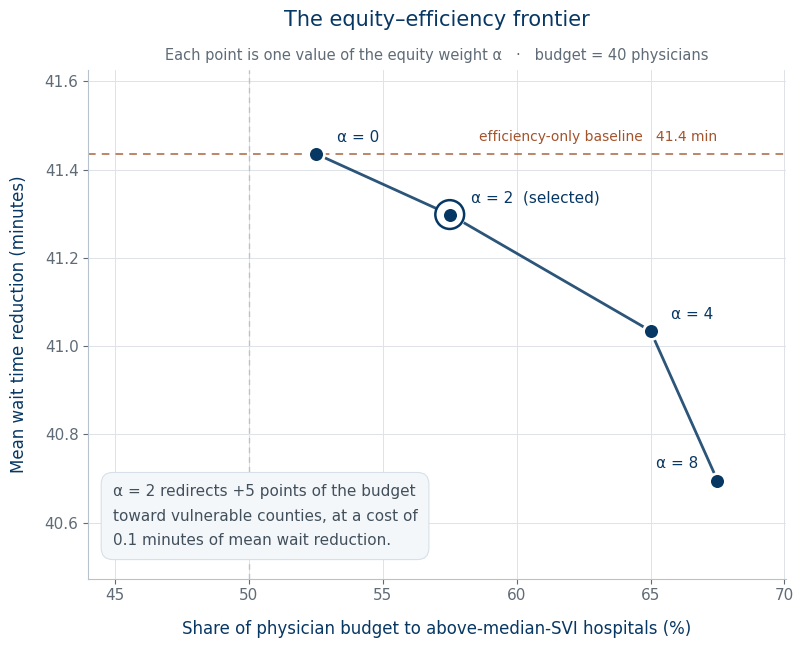

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- sweep ----
share_high, mean_saved = [], []
for a in ALPHA_VALUES:
    t = df.copy()
    t["c"] = t["c_start"].copy()
    t["w"] = 1 + a * t["SVI"]
    res, _ = greedy_equity_allocation(t, BUDGET, verbose=False)
    med = res["SVI"].median()
    gained = res["c"] - res["c_start"]
    share_high.append(100 * gained[res["SVI"] >= med].sum() / BUDGET)
    saved = res.apply(lambda r: (expected_wait(r["c_start"], r["lambda"])
                                 - expected_wait(r["c"], r["lambda"])) * 60, axis=1)
    mean_saved.append(saved.mean())

# ---- figure ----
NAVY, ACCENT, GRID = "#073763", "#A3532B", "#DFE3E8"
CHOSEN = 2
plt.rcParams.update({
    "font.family": "DejaVu Sans", "axes.edgecolor": "#B8C2CC", "axes.linewidth": 0.8,
    "axes.labelcolor": NAVY, "text.color": NAVY,
    "xtick.color": "#5F6B76", "ytick.color": "#5F6B76",
    "xtick.labelsize": 11, "ytick.labelsize": 11, "axes.labelsize": 12,
})

sh, ms = np.array(share_high, float), np.array(mean_saved, float)
i0, ic = ALPHA_VALUES.index(0), ALPHA_VALUES.index(CHOSEN)

fig, ax = plt.subplots(figsize=(9, 6.6))

px, py = (sh.max()-sh.min())*.17, (ms.max()-ms.min())*.30
ax.set_xlim(min(sh.min()-px, 44), sh.max()+px)
ax.set_ylim(ms.min()-py, ms.max()+py*0.85)

ax.axvline(50, color="#B8C2CC", lw=1.0, ls=(0, (4, 3)), zorder=1)
ax.axhline(ms[i0], color=ACCENT, lw=1.1, ls=(0, (5, 4)), alpha=.9, zorder=1)
ax.annotate(f"efficiency-only baseline   {ms[i0]:.1f} min", xy=(sh.max(), ms[i0]),
            xytext=(0, 9), textcoords="offset points", ha="right",
            fontsize=10, color=ACCENT)

ax.plot(sh, ms, color=NAVY, lw=2.0, alpha=.85, zorder=2, solid_capstyle="round")

ax.scatter([sh[ic]], [ms[ic]], s=430, color="white", zorder=3)
ax.scatter([sh[ic]], [ms[ic]], s=430, facecolor="none", edgecolor=NAVY, lw=1.8, zorder=4)
ax.scatter(sh, ms, s=130, color=NAVY, edgecolor="white", lw=2, zorder=5)

xr = ax.get_xlim()[1] - ax.get_xlim()[0]
yr = ax.get_ylim()[1] - ax.get_ylim()[0]
placed = []
for xi, yi, a in zip(sh, ms, ALPHA_VALUES):
    near = any(abs(xi-qx)/xr < 0.09 and abs(yi-qy)/yr < 0.09 for qx, qy in placed)
    right_edge = (ax.get_xlim()[1] - xi)/xr < 0.18
    dx, ha = (-14, "right") if right_edge else (15, "left")
    dy = -20 if near else 12
    lab = f"α = {a}" + ("  (selected)" if a == CHOSEN else "")
    ax.annotate(lab, xy=(xi, yi), xytext=(dx, dy), textcoords="offset points",
                ha=ha, va="center", fontsize=11, color=NAVY, zorder=6)
    placed.append((xi, yi))

d_eq, d_ef = sh[ic] - sh[i0], ms[i0] - ms[ic]
ax.text(0.035, 0.06,
        f"α = {CHOSEN} redirects +{d_eq:.0f} points of the budget\n"
        f"toward vulnerable counties, at a cost of\n"
        f"{d_ef:.1f} minutes of mean wait reduction.",
        transform=ax.transAxes, fontsize=11, color="#42505C",
        linespacing=1.8, va="bottom", ha="left", zorder=6,
        bbox=dict(boxstyle="round,pad=0.75", facecolor="#F4F7FA",
                  edgecolor="#D7E0E8", lw=0.8))

ax.set_xlabel("Share of physician budget to above-median-SVI hospitals (%)", labelpad=12)
ax.set_ylabel("Mean wait time reduction (minutes)", labelpad=12)
ax.grid(color=GRID, lw=.7); ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)

ax.set_title("The equity–efficiency frontier", fontsize=15, color=NAVY, pad=32)
ax.annotate(f"Each point is one value of the equity weight α   ·   budget = {BUDGET} physicians",
            xy=(0.5, 1.020), xycoords="axes fraction", ha="center",
            fontsize=10.5, color="#5F6B76")

plt.savefig("fig2_frontier.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

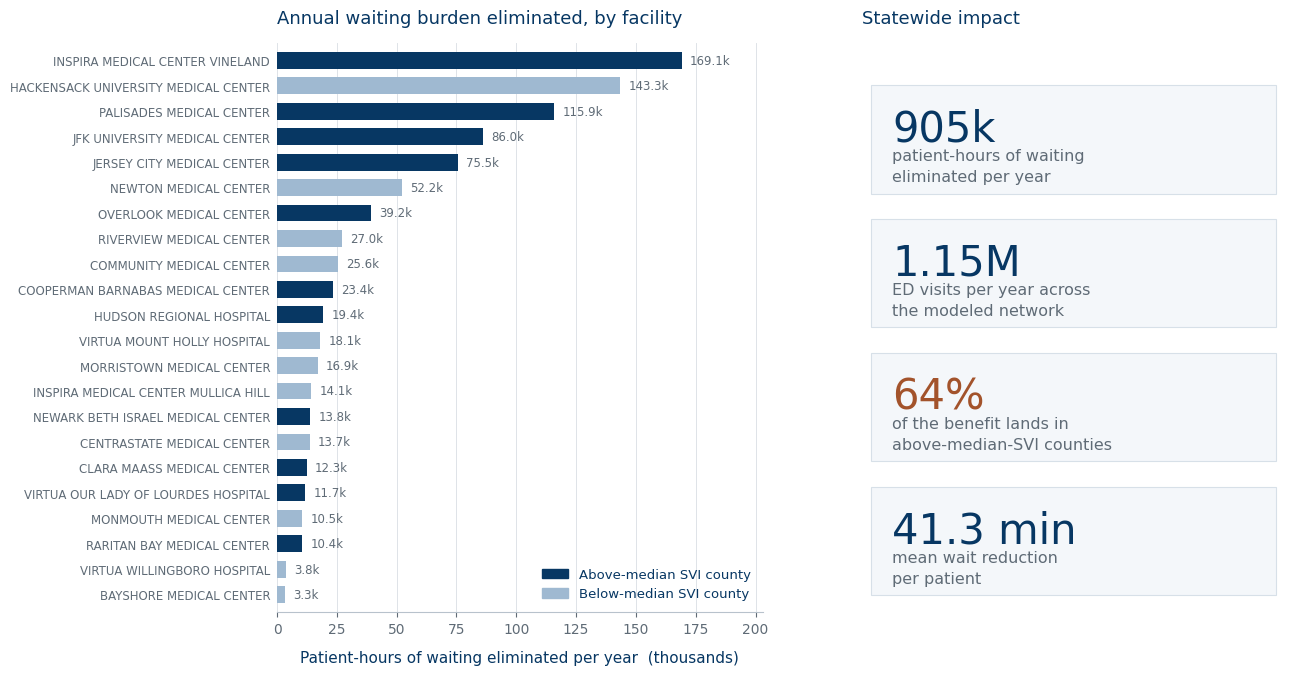

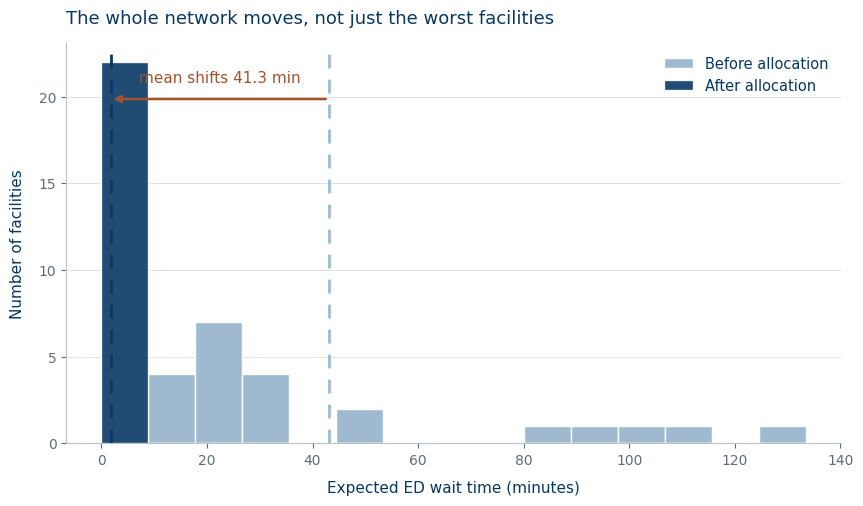

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

NAVY, LIGHT, ACCENT, GRID, MUTED = "#073763", "#9FB9D1", "#A3532B", "#DFE3E8", "#5F6B76"
plt.rcParams.update({
    "font.family": "DejaVu Sans", "axes.edgecolor": "#B8C2CC", "axes.linewidth": 0.8,
    "axes.labelcolor": NAVY, "text.color": NAVY,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.labelsize": 11,
})

HOURS = 8760
final_df["pt_hours_saved"] = final_df.minutes_saved / 60 * final_df["lambda"] * HOURS
final_df["patients_yr"]    = final_df["lambda"] * HOURS

med      = final_df.SVI.median()
total_ph = final_df.pt_hours_saved.sum()
total_pt = final_df.patients_yr.sum()
hi_share = 100 * final_df[final_df.SVI >= med].pt_hours_saved.sum() / total_ph

# ---------- FIGURE E: annual impact ----------
d = final_df.sort_values("pt_hours_saved").reset_index(drop=True)
y = np.arange(len(d))
colors = [NAVY if s >= med else LIGHT for s in d.SVI]

fig = plt.figure(figsize=(13, 7.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.15, 1], wspace=0.22)

axb = fig.add_subplot(gs[0, 0])
axb.barh(y, d.pt_hours_saved / 1000, color=colors, height=.66)
for i, r in d.iterrows():
    axb.annotate(f"{r.pt_hours_saved/1000:,.1f}k", xy=(r.pt_hours_saved / 1000, i),
                 xytext=(6, 0), textcoords="offset points", va="center",
                 fontsize=8.5, color=MUTED)
axb.set_yticks(y)
axb.set_yticklabels(d.hospital, fontsize=8.5)
axb.set_ylim(-0.7, len(d) - 0.3)
axb.set_xlim(0, (d.pt_hours_saved / 1000).max() * 1.20)
axb.set_xlabel("Patient-hours of waiting eliminated per year  (thousands)", labelpad=10)
axb.grid(axis="x", color=GRID, lw=.7)
axb.set_axisbelow(True)
for s in ("top", "right", "left"): axb.spines[s].set_visible(False)
axb.tick_params(axis="y", length=0, pad=5)
axb.legend(handles=[Patch(color=NAVY,  label="Above-median SVI county"),
                    Patch(color=LIGHT, label="Below-median SVI county")],
           loc="lower right", frameon=False, fontsize=9.5)
axb.set_title("Annual waiting burden eliminated, by facility", loc="left",
              fontsize=13, color=NAVY, pad=14)

axn = fig.add_subplot(gs[0, 1])
axn.axis("off")
cards = [
    (f"{total_ph/1000:,.0f}k",              "patient-hours of waiting\neliminated per year",   NAVY),
    (f"{total_pt/1e6:,.2f}M",               "ED visits per year across\nthe modeled network",  NAVY),
    (f"{hi_share:.0f}%",                    "of the benefit lands in\nabove-median-SVI counties", ACCENT),
    (f"{final_df.minutes_saved.mean():.1f} min", "mean wait reduction\nper patient",           NAVY),
]
yy = 0.94
for val, lbl, col in cards:
    axn.add_patch(plt.Rectangle((0.02, yy - 0.205), 0.96, 0.19,
                                transform=axn.transAxes, facecolor="#F4F7FA",
                                edgecolor="#D7E0E8", lw=0.8, zorder=1))
    axn.text(0.07, yy - 0.055, val, transform=axn.transAxes, fontsize=30,
             color=col, va="top", ha="left", zorder=2)
    axn.text(0.07, yy - 0.125, lbl, transform=axn.transAxes, fontsize=11.5,
             color=MUTED, va="top", ha="left", linespacing=1.5, zorder=2)
    yy -= 0.235
axn.set_title("Statewide impact", loc="left", fontsize=13, color=NAVY, pad=14)

plt.savefig("figE_annual_impact.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# ---------- FIGURE F: distribution shift ----------
fig, ax = plt.subplots(figsize=(10, 5.2))
bins = np.linspace(0, final_df.E_W_before_min.max() * 1.05, 16)
ax.hist(final_df.E_W_before_min, bins=bins, color=LIGHT, edgecolor="white",
        lw=1.2, label="Before allocation", zorder=2)
ax.hist(final_df.E_W_after_min, bins=bins, color=NAVY, edgecolor="white",
        lw=1.2, alpha=.9, label="After allocation", zorder=3)

mb, ma = final_df.E_W_before_min.mean(), final_df.E_W_after_min.mean()
ax.axvline(mb, color=LIGHT, lw=2, ls=(0, (5, 4)), zorder=4)
ax.axvline(ma, color=NAVY,  lw=2, ls=(0, (5, 4)), zorder=4)
ax.annotate("", xy=(ma, ax.get_ylim()[1] * .86), xytext=(mb, ax.get_ylim()[1] * .86),
            arrowprops=dict(arrowstyle="-|>", color=ACCENT, lw=1.8))
ax.annotate(f"mean shifts {mb-ma:.1f} min", xy=((mb + ma) / 2, ax.get_ylim()[1] * .90),
            ha="center", fontsize=11, color=ACCENT)

ax.set_xlabel("Expected ED wait time (minutes)", labelpad=10)
ax.set_ylabel("Number of facilities", labelpad=10)
ax.grid(axis="y", color=GRID, lw=.7)
ax.set_axisbelow(True)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.legend(frameon=False, fontsize=10.5, loc="upper right")
ax.set_title("The whole network moves, not just the worst facilities",
             loc="left", fontsize=13, color=NAVY, pad=14)

plt.savefig("figF_distribution_shift.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
print(df['SVI'].describe())
print(df[df['SVI'] < 0][['hospital','county','SVI']])

count    22.000000
mean      0.522727
std       0.304618
min       0.050000
25%       0.250000
50%       0.525000
75%       0.737500
max       1.000000
Name: SVI, dtype: float64
Empty DataFrame
Columns: [hospital, county, SVI]
Index: []


In [ ]:
HOURS = 8760

def alloc_metrics(res, label):
    r = res.copy()
    r['minutes_saved'] = r.apply(
        lambda x: (expected_wait(x['c_start'], x['lambda'])
                   - expected_wait(x['c'], x['lambda'])) * 60, axis=1)
    r['patients_yr']  = r['lambda'] * HOURS
    r['pt_hours']     = r['minutes_saved'] / 60 * r['patients_yr']
    r['gained']       = r['c'] - r['c_start']

    med  = r['SVI'].median()
    hi   = r['SVI'] >= med

    return {
        'alpha': label,
        'mean_min_per_hospital': r['minutes_saved'].mean(),
        'mean_min_per_patient':  r['pt_hours'].sum() * 60 / r['patients_yr'].sum(),
        'total_pt_hours':        r['pt_hours'].sum(),
        'pct_budget_highSVI':    100 * r.loc[hi, 'gained'].sum() / BUDGET,
        'pct_pt_hours_highSVI':  100 * r.loc[hi, 'pt_hours'].sum() / r['pt_hours'].sum(),
        'worst_wait_after_min':  (r.apply(lambda x: expected_wait(x['c'], x['lambda']), axis=1) * 60).max(),
    }, r

m0, d0 = alloc_metrics(r0, 0)
m2, d2 = alloc_metrics(r2, ALPHA)

comp = pd.DataFrame([m0, m2]).set_index('alpha').T
comp['delta']   = comp[ALPHA] - comp[0]
comp['pct_chg'] = 100 * comp['delta'] / comp[0]
display(comp.round(3))

print(f"\nefficiency cost: {m0['total_pt_hours'] - m2['total_pt_hours']:,.0f} patient-hours "
      f"({100*(m0['total_pt_hours']-m2['total_pt_hours'])/m0['total_pt_hours']:.2f}% of the α=0 total)")
print(f"equity gain:     {m2['pct_pt_hours_highSVI'] - m0['pct_pt_hours_highSVI']:+.1f} pp "
      f"of benefit share to above-median-SVI counties")

alpha,0.0,2.0,delta,pct_chg
mean_min_per_hospital,41.436,41.298,-0.138,-0.332
mean_min_per_patient,47.528,47.412,-0.116,-0.244
total_pt_hours,907487.126,905269.081,-2218.045,-0.244
pct_budget_highSVI,52.500,57.500,5.000,9.524
pct_pt_hours_highSVI,63.235,63.712,0.477,0.754
worst_wait_after_min,3.544,5.054,1.510,42.604



efficiency cost: 2,218 patient-hours (0.24% of the α=0 total)
equity gain:     +0.5 pp of benefit share to above-median-SVI counties


In [ ]:
chk = df.copy()
chk['E_W_at_cstart_min'] = chk.apply(lambda r: expected_wait(r['c_start'], r['lambda']) * 60, axis=1)
chk['observed_min']      = chk['Wq_hours'] * 60
chk['ratio']             = chk['E_W_at_cstart_min'] / chk['observed_min']
display(chk[['hospital','lambda','implied_c','c_start','observed_min','E_W_at_cstart_min','ratio']]
        .sort_values('ratio'))
print("mean ratio:", chk['ratio'].mean().round(3))

,hospital,lambda,implied_c,c_start,observed_min,E_W_at_cstart_min,ratio
20,BAYSHORE MEDICAL CENTER,2.748916,1.206028,2,166.0,9.635098,0.058043
13,VIRTUA WILLINGBORO HOSPITAL,2.845186,1.234544,2,181.0,10.632064,0.058741
14,INSPIRA MEDICAL CENTER MULLICA HILL,7.792009,3.176321,4,182.0,13.281981,0.072978
4,MORRISTOWN MEDICAL CENTER,6.027648,2.457243,3,240.0,23.212922,0.096721
1,NEWARK BETH ISRAEL MEDICAL CENTER,5.704789,2.366595,3,169.0,17.308565,0.102418
12,VIRTUA MOUNT HOLLY HOSPITAL,5.957705,2.443828,3,207.0,21.734281,0.104997
19,CENTRASTATE MEDICAL CENTER,3.769942,1.580810,2,219.0,28.345814,0.129433
9,RARITAN BAY MEDICAL CENTER,3.583351,1.531993,2,174.0,22.941271,0.131846
6,VIRTUA OUR LADY OF LOURDES HOSPITAL,3.665510,1.574192,2,161.0,25.142302,0.156163
10,COMMUNITY MEDICAL CENTER,6.256151,2.575509,3,182.0,29.115812,0.159977


mean ratio: 0.231


In [ ]:
BUDGETS = [1, 2, 3, 5, 8, 12, 20, 40]
ALPHAS  = [0, 2]
BASELINE_CAP = df['c_start'].sum()

rows = []
for B in BUDGETS:
    for a in ALPHAS:
        t = df.copy()
        t['c'] = t['c_start'].copy()
        t['w'] = 1 + a * t['SVI']
        res, _ = greedy_equity_allocation(t, B, verbose=False)
        res['gained'] = res['c'] - res['c_start']
        med = res['SVI'].median()
        saved = res.apply(lambda r: (expected_wait(r['c_start'], r['lambda'])
                                     - expected_wait(r['c'], r['lambda'])) * 60, axis=1)
        after = res.apply(lambda r: expected_wait(r['c'], r['lambda']) * 60, axis=1)
        pt_hrs = (saved / 60 * res['lambda'] * 8760)
        rows.append({
            'budget': B, 'alpha': a,
            'pct_of_baseline': 100 * B / BASELINE_CAP,
            'mean_saved_min': saved.mean(),
            'pt_hours_saved': pt_hrs.sum(),
            'worst_after_min': after.max(),
            'pct_budget_highSVI': 100 * res.loc[res.SVI >= med, 'gained'].sum() / B,
            'pct_pt_hours_highSVI': 100 * pt_hrs[res.SVI >= med].sum() / pt_hrs.sum(),
        })

sweep = pd.DataFrame(rows)
display(sweep.round(2))

piv = sweep.pivot(index='budget', columns='alpha', values='pct_budget_highSVI')
piv['shift_pp'] = piv[2] - piv[0]
eff = sweep.pivot(index='budget', columns='alpha', values='mean_saved_min')
piv['eff_cost_pct'] = 100 * (eff[0] - eff[2]) / eff[0]
display(piv.round(2))
print(f"\noperative band: budgets where |shift| > 5pp → "
      f"{piv.index[piv['shift_pp'].abs() > 5].tolist()}")

,budget,alpha,pct_of_baseline,mean_saved_min,pt_hours_saved,worst_after_min,pct_budget_highSVI,pct_pt_hours_highSVI
0,1,0,1.85,8.68,339996.42,240.00,100.00,100.00
1,1,2,1.85,8.68,339996.42,240.00,100.00,100.00
2,2,0,3.70,16.76,643005.24,240.00,100.00,100.00
3,2,2,3.70,16.76,643005.24,240.00,100.00,100.00
4,3,0,5.55,25.15,903896.30,240.00,66.67,71.14
5,3,2,5.55,24.97,876208.18,240.00,100.00,100.00
6,5,0,9.25,42.24,1341627.97,240.00,80.00,80.55
7,5,2,9.25,42.24,1341627.97,240.00,80.00,80.55
8,8,0,14.81,69.44,1910665.77,219.00,50.00,56.56
9,8,2,14.81,62.31,1765750.59,240.00,75.00,76.34


alpha,0,2,shift_pp,eff_cost_pct
budget,,,,
1,100.00,100.00,0.00,0.00
2,100.00,100.00,0.00,0.00
3,66.67,100.00,33.33,0.73
5,80.00,80.00,0.00,0.00
8,50.00,75.00,25.00,10.28
12,58.33,58.33,0.00,0.00
20,55.00,55.00,0.00,1.51
40,52.50,60.00,7.50,0.08



operative band: budgets where |shift| > 5pp → [3, 8, 40]


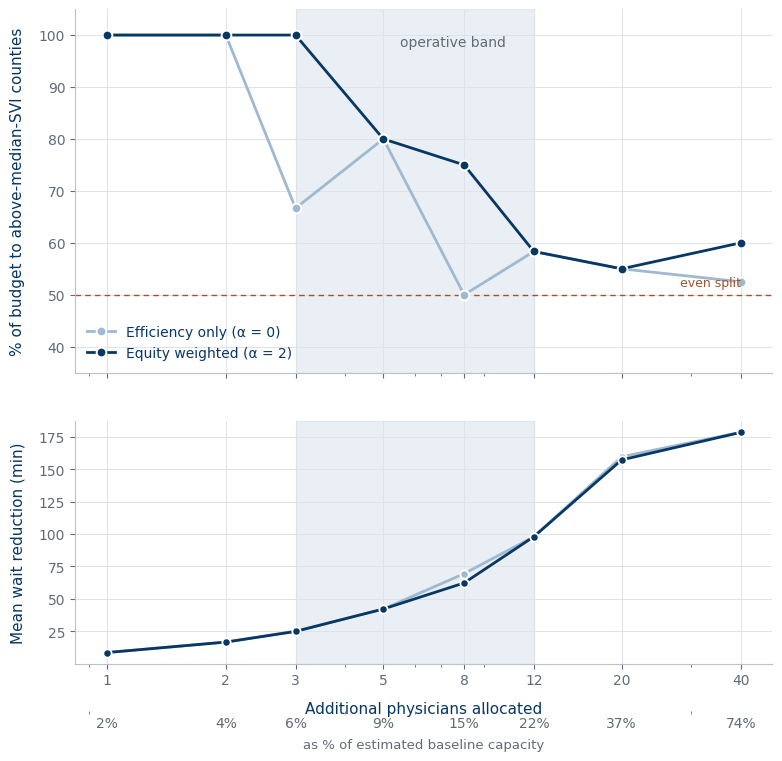

In [ ]:
import matplotlib.pyplot as plt

NAVY, LIGHT, ACCENT, GRID, MUTED = "#073763", "#9FB9D1", "#A3532B", "#DFE3E8", "#5F6B76"
plt.rcParams.update({
    "font.family": "DejaVu Sans", "axes.edgecolor": "#B8C2CC", "axes.linewidth": 0.8,
    "axes.labelcolor": NAVY, "text.color": NAVY,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.labelsize": 11,
})

s0 = sweep[sweep.alpha == 0].set_index('budget')
s2 = sweep[sweep.alpha == 2].set_index('budget')
x = s0.index.values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8.5), sharex=True,
                               gridspec_kw={"height_ratios": [1.5, 1], "hspace": 0.16})

LO, HI = 3, 12
ax1.axvspan(LO, HI, color=LIGHT, alpha=.22, zorder=0)
ax1.annotate("operative band", xy=((LO+HI)/2, 100), ha="center", va="top",
             fontsize=10, color=MUTED)

ax1.plot(x, s0['pct_budget_highSVI'], 'o-', color=LIGHT, lw=2, ms=7,
         mec="white", mew=1.4, label="Efficiency only (α = 0)", zorder=3)
ax1.plot(x, s2['pct_budget_highSVI'], 'o-', color=NAVY, lw=2, ms=7,
         mec="white", mew=1.4, label=f"Equity weighted (α = {ALPHA:.0f})", zorder=3)
ax1.axhline(50, color=ACCENT, lw=1.0, ls=(0, (4, 3)), zorder=1)
ax1.annotate("even split", xy=(x.max(), 50), xytext=(0, 6),
             textcoords="offset points", ha="right", fontsize=9, color=ACCENT)

ax1.set_ylabel("% of budget to above-median-SVI counties", labelpad=10)
ax1.set_ylim(35, 105)
ax1.legend(frameon=False, fontsize=10, loc="lower left")
ax1.grid(color=GRID, lw=.7); ax1.set_axisbelow(True)
for s in ("top", "right"): ax1.spines[s].set_visible(False)

ax2.axvspan(LO, HI, color=LIGHT, alpha=.22, zorder=0)
ax2.plot(x, s0['mean_saved_min'], 'o-', color=LIGHT, lw=2, ms=6, mec="white", mew=1.3)
ax2.plot(x, s2['mean_saved_min'], 'o-', color=NAVY, lw=2, ms=6, mec="white", mew=1.3)
ax2.set_ylabel("Mean wait reduction (min)", labelpad=10)
ax2.set_xlabel("Additional physicians allocated", labelpad=10)
ax2.set_xscale('log'); ax2.set_xticks(x); ax2.set_xticklabels(x)
ax2.grid(color=GRID, lw=.7); ax2.set_axisbelow(True)
for s in ("top", "right"): ax2.spines[s].set_visible(False)

secax = ax2.secondary_xaxis('bottom', functions=(lambda v: v, lambda v: v))
secax.set_xticks(x)
secax.set_xticklabels([f"{100*b/BASELINE_CAP:.0f}%" for b in x], fontsize=8.5, color=MUTED)
secax.spines['bottom'].set_position(('outward', 34))
secax.spines['bottom'].set_visible(False)
secax.tick_params(length=0)
secax.set_xlabel("as % of estimated baseline capacity", fontsize=9.5, color=MUTED, labelpad=6)

plt.savefig("fig_budget_band.png", dpi=300, bbox_inches="tight")
plt.show()